In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from my_utils import Bil_layer

/home/asinix/miniconda3/envs/ma_env/lib/python3.12/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [3]:
# parameters
DATA_ROOT_PATH = './imagenet10'
DATA_CHANNEL = 3 # RGB
DATA_DIM = 256 # height and width
CLASS_LABLES = 10
TRAIN_TEST_SPLIT = [0.8, 0.2]
BATCH_SIZE = 64
EPOCHS = 5

torch.manual_seed(1)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f'operation running on {device}')

operation running on cuda:0


In [4]:
##** Data Preparation **##

transform = transforms.Compose([
    transforms.Resize((DATA_DIM, DATA_DIM)),
    transforms.ToTensor()
])


dataset = datasets.ImageFolder(root=DATA_ROOT_PATH, transform=transform)
print(len(dataset))
# print(dataset.imgs[0])

train_set, test_set = torch.utils.data.random_split(
    dataset,
    TRAIN_TEST_SPLIT) 
print(len(train_set))
print(len(test_set))

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last = True)
test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False, # no need to shuffle test data
    drop_last = True)
sample_idx = np.random.randint(0, len(test_set))

12988
10391
2597


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


bil= 10  median= 0  blur= (0, 0)  noise= 0.008  color2= 0.06  sup= 0  jpeg= 0 q= 75


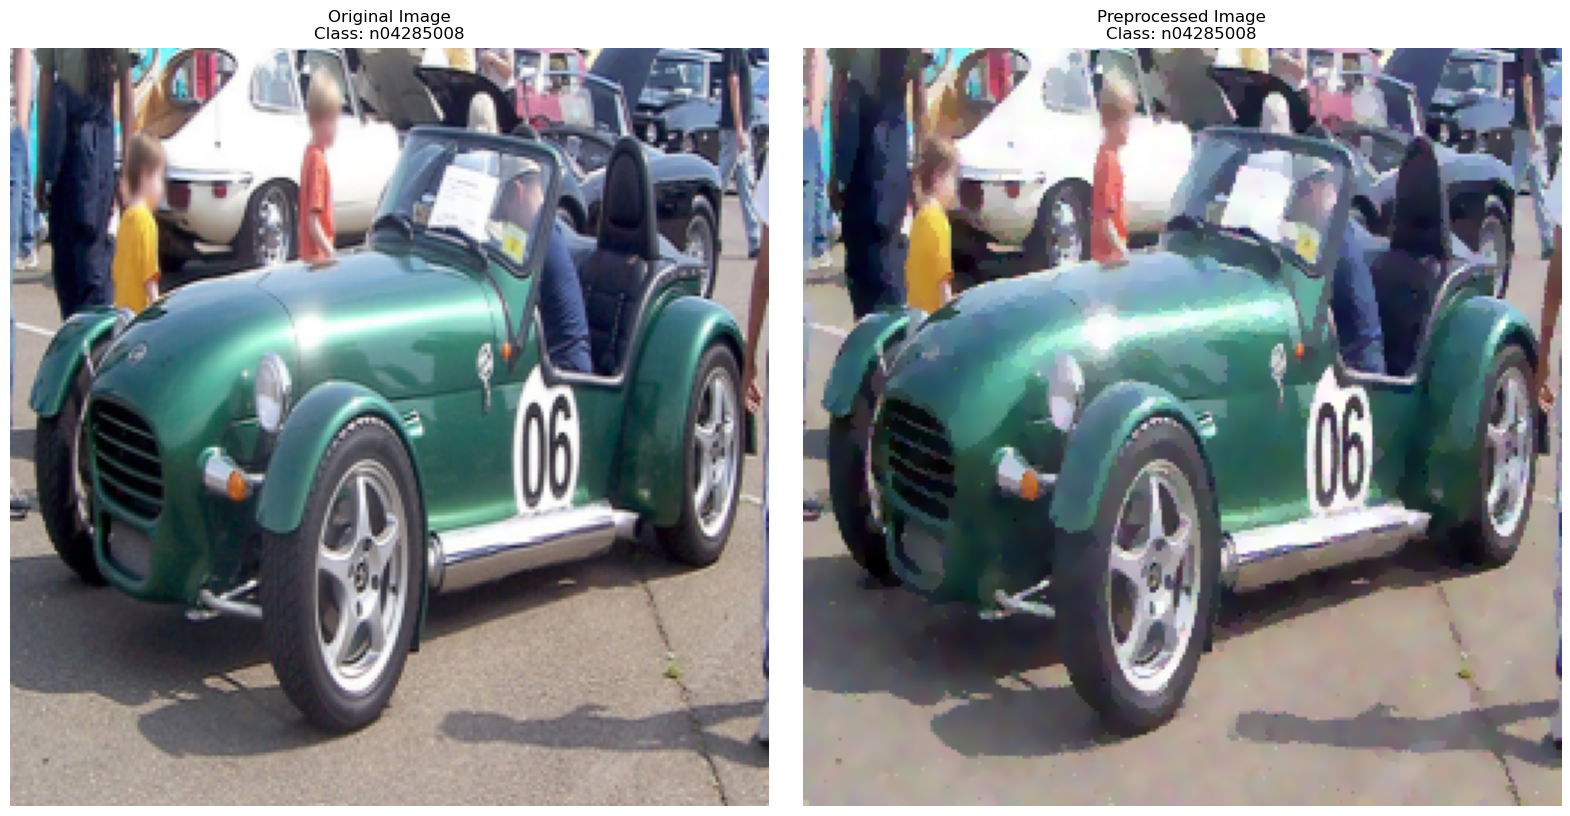

Image shape: torch.Size([3, 256, 256])
Preprocessed image shape: torch.Size([3, 256, 256])
Class index: 7
Class name: n04285008
Original pixel value range: [0.000, 1.000]
Preprocessed pixel value range: [-0.123, 1.193]


In [18]:
# Get the first sample from the test set

sample_image, sample_label = test_set[sample_idx]

preproc = Bil_layer(bil=10, sigma_color=0.4, color2 = 0.06 , noise=0.008, sigma_space=1, kernel_size=5, device="cpu")
preproc_sample_image = preproc(sample_image.unsqueeze(0))

# Convert the tensors to numpy for visualization
sample_image_np = sample_image.permute(1, 2, 0).numpy()
preproc_sample_image_np = preproc_sample_image[0].permute(1, 2, 0).numpy()

# Get class names if available
class_names = dataset.classes if hasattr(dataset, 'classes') else [f"Class {i}" for i in range(len(dataset.class_to_idx))]

# Create a figure with two subplots side by side
plt.figure(figsize=(16, 8))

# Plot original image on the left
plt.subplot(1, 2, 1)
plt.imshow(sample_image_np)
plt.title(f"Original Image\nClass: {class_names[sample_label]}")
plt.axis('off')

# Plot preprocessed image on the right
plt.subplot(1, 2, 2)
plt.imshow(preproc_sample_image_np)
plt.title(f"Preprocessed Image\nClass: {class_names[sample_label]}")
plt.axis('off')

plt.tight_layout()
plt.show()

# Print information about the images
print(f"Image shape: {sample_image.shape}")
print(f"Preprocessed image shape: {preproc_sample_image[0].shape}")
print(f"Class index: {sample_label}")
print(f"Class name: {class_names[sample_label]}")
print(f"Original pixel value range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print(f"Preprocessed pixel value range: [{preproc_sample_image.min():.3f}, {preproc_sample_image.max():.3f}]")